# Movies Revenue and Ratings Prediction: EDA

Data collection, cleaning, feature engineering, and EDA.

In [ ]:
#Imports
import os, json, time, math
from collections import Counter
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

pd.set_option('display.max_columns', 80)
sns.set_theme(style='whitegrid')

In [ ]:
#API config
TMDB_API_KEY = '1bd7ac17f8ee965418cfbb7d2bed1be8'
TMDB_BASE = 'https://api.themoviedb.org/3'

os.makedirs('data', exist_ok=True)
os.makedirs('eda_outputs', exist_ok=True)

## 1. Data Collection

In [ ]:
# movie IDs by year(sorted by revenue)
def discover_year(year, max_pages=25):
    ids = []
    for page in range(1, max_pages + 1):
        params = {
            'api_key': TMDB_API_KEY,
            'sort_by': 'revenue.desc',
            'primary_release_year': year,
            'page': page,
            'include_adult': 'false',
            'language': 'en-US',
        }
        r = requests.get(f'{TMDB_BASE}/discover/movie', params=params, timeout=20)
        if r.status_code != 200:
            break
        results = r.json().get('results', [])
        if not results:
            break
        ids.extend([m['id'] for m in results])
        time.sleep(0.05)
    return ids

YEARS = list(range(2010, 2025))
all_ids = []
for y in tqdm(YEARS):
    all_ids.extend(discover_year(y, max_pages=25))
all_ids = list(dict.fromkeys(all_ids))  # dedupe, keep order
print('Unique movie IDs:', len(all_ids))
with open('data/movie_ids.json', 'w') as f:
    json.dump(all_ids, f)

100%|██████████| 15/15 [00:52<00:00,  3.53s/it]

Unique movie IDs: 7500


In [ ]:
# Fetch full movie details
#can resume
DETAILS_PATH = 'data/raw_details.json'
if os.path.exists(DETAILS_PATH):
    with open(DETAILS_PATH) as f:
        details_map = json.load(f)
else:
    details_map = {}

def fetch_detail(mid):
    params = {'api_key': TMDB_API_KEY, 'append_to_response': 'credits,keywords', 'language': 'en-US'}
    r = requests.get(f'{TMDB_BASE}/movie/{mid}', params=params, timeout=20)
    if r.status_code == 200:
        return r.json()
    return None

for i, mid in enumerate(tqdm(all_ids)):
    key = str(mid)
    if key in details_map:
        continue
    d = fetch_detail(mid)
    if d:
        details_map[key] = d
    if i % 200 == 0:
        with open(DETAILS_PATH, 'w') as f:
            json.dump(details_map, f)
    time.sleep(0.03)

with open(DETAILS_PATH, 'w') as f:
    json.dump(details_map, f)
details = list(details_map.values())
print('Fetched details:', len(details))

100%|██████████| 7500/7500 [13:53<00:00,  9.00it/s]


Fetched details: 7500


In [ ]:
#Build dataframe(raw)
def parse_row(m):
    cast = m.get('credits', {}).get('cast', []) or []
    crew = m.get('credits', {}).get('crew', []) or []
    directors = [c for c in crew if c.get('job') == 'Director']
    return {
        'movie_id': m.get('id'),
        'imdb_id': m.get('imdb_id'),
        'title': m.get('title'),
        'release_date': m.get('release_date'),
        'runtime': m.get('runtime'),
        'budget': m.get('budget'),
        'revenue': m.get('revenue'),
        'original_language': m.get('original_language'),
        'popularity': m.get('popularity'),
        'tmdb_vote_average': m.get('vote_average'),
        'tmdb_vote_count': m.get('vote_count'),
        'adult': m.get('adult'),
        'status': m.get('status'),
        'overview': m.get('overview') or '',
        'tagline': m.get('tagline') or '',
        'genres': [g['name'] for g in m.get('genres', [])],
        'production_companies': [c['name'] for c in m.get('production_companies', [])],
        'production_countries': [c['iso_3166_1'] for c in m.get('production_countries', [])],
        'keywords': [k['name'] for k in m.get('keywords', {}).get('keywords', [])],
        'cast_names': [c['name'] for c in cast[:10]],
        'cast_popularities': [c.get('popularity', 0) for c in cast[:10]],
        'num_cast': len(cast),
        'director_names': [d['name'] for d in directors],
        'director_popularities': [d.get('popularity', 0) for d in directors],
    }

raw_df = pd.DataFrame([parse_row(m) for m in details])
#store the dataframe for modeling
raw_df.to_pickle('data/raw_movies.pkl')
print(raw_df.shape)
raw_df.head()

(7500, 24)


,movie_id,imdb_id,title,release_date,runtime,budget,revenue,original_language,popularity,tmdb_vote_average,tmdb_vote_count,adult,status,overview,tagline,genres,production_companies,production_countries,keywords,cast_names,cast_popularities,num_cast,director_names,director_popularities
0,10193,tt0435761,Toy Story 3,2010-06-16,102,200000000,1067316101,en,15.3618,7.804,15655,False,Released,"Woody, Buzz, and the rest of Andy's toys haven...",No toy gets left behind.,"[Animation, Family, Comedy]",[Pixar],[US],"[escape, hostage, college, villain, sequel, bu...","[Tom Hanks, Tim Allen, Joan Cusack, Don Rickle...","[13.1439, 3.729, 3.0282, 2.5204, 3.368, 2.3112...",60,[Lee Unkrich],[1.0261]
1,12155,tt1014759,Alice in Wonderland,2010-03-03,108,200000000,1025467110,en,10.7705,6.639,14742,False,Released,"Alice, now 19 years old, returns to the whimsi...",You're invited to a very important date.,"[Family, Fantasy, Adventure]","[Walt Disney Pictures, Roth Films, Team Todd, ...",[US],"[based on novel or book, queen, based on child...","[Mia Wasikowska, Johnny Depp, Anne Hathaway, H...","[2.1955, 7.283, 24.4937, 3.8135, 2.2826, 1.505...",58,[Tim Burton],[3.0735]
2,12444,tt0926084,Harry Potter and the Deathly Hallows: Part 1,2010-11-17,146,250000000,954305868,en,19.7287,7.734,20289,False,Released,"Harry, Ron and Hermione walk away from their l...",Nowhere is safe.,"[Adventure, Fantasy]","[Warner Bros. Pictures, Heyday Films]","[GB, US]","[witch, friendship, london, england, corruptio...","[Daniel Radcliffe, Emma Watson, Rupert Grint, ...","[8.794, 9.2289, 3.1329, 2.4414, 3.8135, 2.8823...",106,[David Yates],[1.1437]
3,27205,tt1375666,Inception,2010-07-15,148,160000000,839030630,en,30.1681,8.372,39119,False,Released,"Cobb, a skilled thief who commits corporate es...",Your mind is the scene of the crime.,"[Action, Science Fiction, Adventure]","[Legendary Pictures, Syncopy, Warner Bros. Pic...","[GB, US]","[mission, dreams, kidnapping, spy, allegory, i...","[Leonardo DiCaprio, Joseph Gordon-Levitt, Ken ...","[8.6116, 3.9658, 3.9288, 13.8854, 4.9504, 0.92...",52,[Christopher Nolan],[8.2929]
4,10192,tt0892791,Shrek Forever After,2010-05-20,93,165000000,752600867,en,10.3550,6.394,7908,False,Released,"A midlife-crisis burdened Shrek, longing for t...",It ain't ogre...til it's ogre.,"[Comedy, Adventure, Fantasy, Animation, Family]",[DreamWorks Animation],[US],"[witch, villain, sequel, aftercreditsstinger, ...","[Mike Myers, Eddie Murphy, Cameron Diaz, Anton...","[4.5132, 4.8953, 7.4377, 4.5058, 0.6475, 2.307...",35,[Mike Mitchell],[0.9688]


In [ ]:
#Feature engineering
df = raw_df.copy()
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_quarter'] = df['release_date'].dt.quarter
df['release_dayofweek'] = df['release_date'].dt.dayofweek
df['is_summer_release'] = df['release_month'].isin([5, 6, 7, 8]).astype(int)
df['is_holiday_season_release'] = df['release_month'].isin([11, 12]).astype(int)

# Log transforms
df['log_revenue'] = np.log1p(df['revenue'].clip(lower=0))
df['log_budget']  = np.log1p(df['budget'].clip(lower=0))

# Genre features
df['num_genres'] = df['genres'].apply(len)
df['num_production_companies'] = df['production_companies'].apply(len)
df['num_production_countries'] = df['production_countries'].apply(len)
df['is_us_production'] = df['production_countries'].apply(lambda xs: 'US' in xs).astype(int)
df['is_international_coproduction'] = (df['num_production_countries'] > 1).astype(int)

# Cast features
df['top_cast_popularity']  = df['cast_popularities'].apply(lambda xs: xs[0] if xs else 0)
df['top3_cast_avg_pop']    = df['cast_popularities'].apply(lambda xs: np.mean(xs[:3]) if xs else 0)
df['top5_cast_avg_pop']    = df['cast_popularities'].apply(lambda xs: np.mean(xs[:5]) if xs else 0)
df['max_cast_popularity']  = df['cast_popularities'].apply(lambda xs: max(xs) if xs else 0)
df['director_popularity']  = df['director_popularities'].apply(lambda xs: max(xs) if xs else 0)

# Text features
df['overview_length'] = df['overview'].str.len()
df['tagline_length']  = df['tagline'].str.len()
df['has_tagline']     = (df['tagline_length'] > 0).astype(int)
df['num_keywords']    = df['keywords'].apply(len)

df.to_pickle('data/features_movies.pkl')
print(df.shape)

(7500, 46)


## 2. Data Checking & Cleaning

In [ ]:
#Missing-value
miss = df.isna().mean().sort_values(ascending=False).reset_index()
miss.columns = ['column', 'missing_ratio']
miss.head(20)

,column,missing_ratio
0,imdb_id,0.02
1,movie_id,0.00
2,num_production_countries,0.00
3,release_month,0.00
4,release_quarter,0.00
5,release_dayofweek,0.00
6,is_summer_release,0.00
7,is_holiday_season_release,0.00
8,log_revenue,0.00
9,log_budget,0.00


In [ ]:
#build dataset (clean)
mask = (
    (df['runtime'].fillna(0) > 40) &
    (df['budget'] > 0) &
    (df['revenue'] > 0) &
    (df['tmdb_vote_count'] >= 50) &
    (df['adult'] == False) &
    (df['release_year'].between(2010, 2024))
)
df_clean = df[mask].copy()
# Binary label for secondary task (adjust threshold after viewing distribution)
df_clean['high_rating'] = (df_clean['tmdb_vote_average'] >= 7.0).astype('Int64')
df_clean.to_pickle('data/clean_movies.pkl')
print('Clean shape:', df_clean.shape)

Clean shape: (3532, 47)


## Part 2: Revenue Distribution

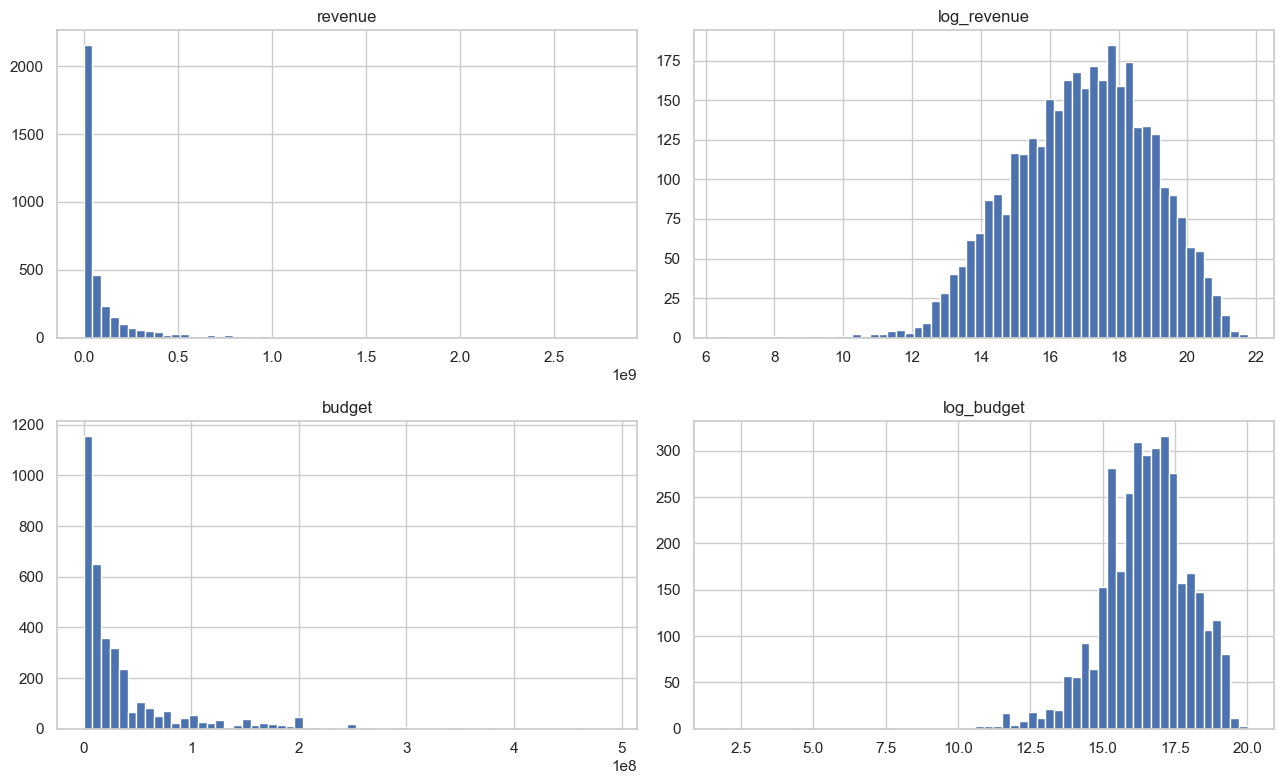

,variable,count,mean,std,min,25%,50%,75%,max
0,revenue,3532.0,1.054244e+08,2.160065e+08,618.000000,5.511040e+06,2.576870e+07,9.705786e+07,2.799439e+09
1,log_revenue,3532.0,1.694117e+01,1.990234e+00,6.428105,1.552226e+01,1.706467e+01,1.839082e+01,2.175268e+01
2,budget,3532.0,3.558862e+07,5.108694e+07,5.000000,6.000000e+06,1.545000e+07,4.000000e+07,4.899000e+08
3,log_budget,3532.0,1.650353e+01,1.508765e+00,1.791759,1.560727e+01,1.655311e+01,1.750439e+01,2.000971e+01


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].hist(df_clean['revenue'], bins=60); axes[0, 0].set_title('revenue')
axes[0, 1].hist(df_clean['log_revenue'], bins=60); axes[0, 1].set_title('log_revenue')
axes[1, 0].hist(df_clean['budget'], bins=60); axes[1, 0].set_title('budget')
axes[1, 1].hist(df_clean['log_budget'], bins=60); axes[1, 1].set_title('log_budget')
plt.tight_layout()
plt.show()

rev_summary = df_clean[['revenue', 'log_revenue', 'budget', 'log_budget']].describe().T.reset_index().rename(columns={'index': 'variable'})
rev_summary

## Part 3: Time Analysis

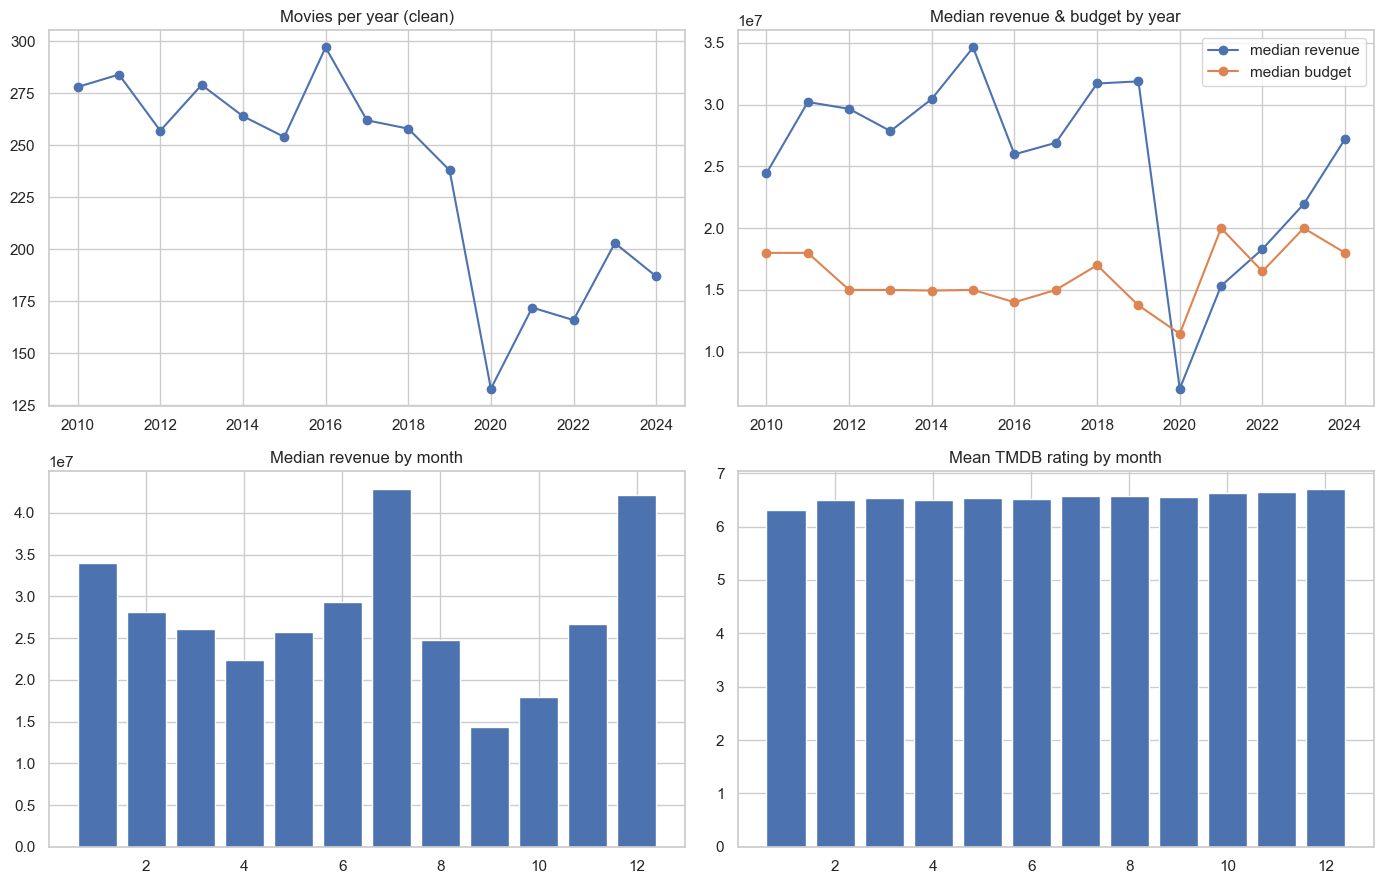

In [ ]:
#Yearly / monthly / quarterly trends
year_stats = df_clean.groupby('release_year').agg(
    n_movies=('movie_id', 'count'),
    mean_revenue=('revenue', 'mean'),
    median_revenue=('revenue', 'median'),
    mean_budget=('budget', 'mean'),
    median_budget=('budget', 'median'),
    mean_tmdb_rating=('tmdb_vote_average', 'mean'),
).reset_index()

month_stats = df_clean.groupby('release_month').agg(
    n_movies=('movie_id', 'count'),
    median_revenue=('revenue', 'median'),
    mean_log_revenue=('log_revenue', 'mean'),
    mean_tmdb_rating=('tmdb_vote_average', 'mean'),
).reset_index()

quarter_stats = df_clean.groupby('release_quarter').agg(
    n_movies=('movie_id', 'count'),
    median_revenue=('revenue', 'median'),
    mean_log_revenue=('log_revenue', 'mean'),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(year_stats['release_year'], year_stats['n_movies'], marker='o')
axes[0, 0].set_title('Movies per year (clean)')
axes[0, 1].plot(year_stats['release_year'], year_stats['median_revenue'], marker='o', label='median revenue')
axes[0, 1].plot(year_stats['release_year'], year_stats['median_budget'], marker='o', label='median budget')
axes[0, 1].legend(); axes[0, 1].set_title('Median revenue & budget by year')
axes[1, 0].bar(month_stats['release_month'], month_stats['median_revenue'])
axes[1, 0].set_title('Median revenue by month')
axes[1, 1].bar(month_stats['release_month'], month_stats['mean_tmdb_rating'])
axes[1, 1].set_title('Mean TMDB rating by month')
plt.tight_layout()
plt.show()

## Part 4: Genre Analysis

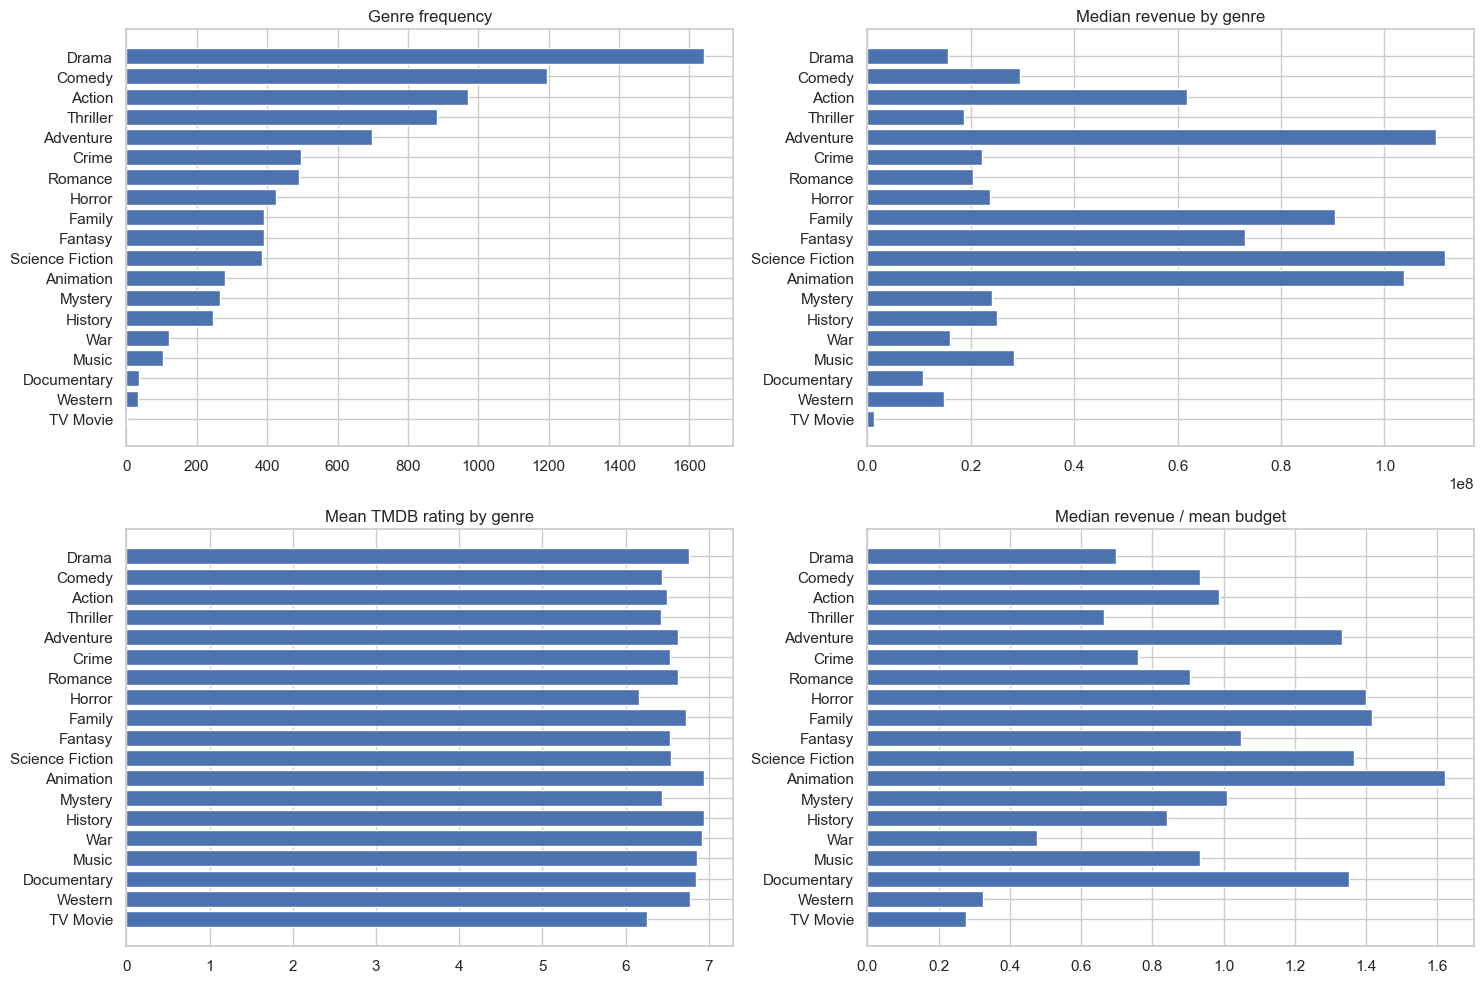

,genre,n_movies,median_revenue,mean_log_revenue,mean_budget,mean_tmdb_rating,revenue_budget_ratio
6,Drama,1642,15575000.0,16.462285,2.230346e+07,6.765817,0.698322
3,Comedy,1196,29504201.5,17.061434,3.160493e+07,6.433661,0.933532
0,Action,970,61884095.0,17.639447,6.275417e+07,6.495400,0.986135
16,Thriller,883,18685751.0,16.650190,2.818894e+07,6.424630,0.662875
1,Adventure,697,109906372.0,18.138895,8.252412e+07,6.633539,1.331809
4,Crime,495,22126842.0,16.683204,2.909970e+07,6.536552,0.760381
13,Romance,490,20436345.5,16.777181,2.253503e+07,6.624867,0.906870
10,Horror,426,23782966.5,16.701133,1.698380e+07,6.163082,1.400333
7,Family,391,90497778.0,18.045605,6.393076e+07,6.725570,1.415559
8,Fantasy,390,73003463.0,17.723352,6.953336e+07,6.531718,1.049906


In [ ]:
#Genre stats
rows = []
for _, r in df_clean.iterrows():
    for g in r['genres']:
        rows.append({'genre': g, 'revenue': r['revenue'], 'budget': r['budget'],
                     'log_revenue': r['log_revenue'],
                     'tmdb_vote_average': r['tmdb_vote_average']})
genre_long = pd.DataFrame(rows)

genre_stats = genre_long.groupby('genre').agg(
    n_movies=('revenue', 'count'),
    median_revenue=('revenue', 'median'),
    mean_log_revenue=('log_revenue', 'mean'),
    mean_budget=('budget', 'mean'),
    mean_tmdb_rating=('tmdb_vote_average', 'mean'),
).reset_index()
genre_stats['revenue_budget_ratio'] = genre_stats['median_revenue'] / genre_stats['mean_budget']
genre_stats = genre_stats.sort_values('n_movies', ascending=False)

ng_stats = df_clean.groupby('num_genres').agg(
    n_movies=('movie_id', 'count'),
    median_revenue=('revenue', 'median'),
    mean_log_revenue=('log_revenue', 'mean'),
).reset_index()

top = genre_stats.head(20)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0, 0].barh(top['genre'], top['n_movies']); axes[0, 0].invert_yaxis(); axes[0, 0].set_title('Genre frequency')
axes[0, 1].barh(top['genre'], top['median_revenue']); axes[0, 1].invert_yaxis(); axes[0, 1].set_title('Median revenue by genre')
axes[1, 0].barh(top['genre'], top['mean_tmdb_rating']); axes[1, 0].invert_yaxis(); axes[1, 0].set_title('Mean TMDB rating by genre')
axes[1, 1].barh(top['genre'], top['revenue_budget_ratio']); axes[1, 1].invert_yaxis(); axes[1, 1].set_title('Median revenue / mean budget')
plt.tight_layout()
plt.show()
genre_stats

## Part 5: Production Analysis

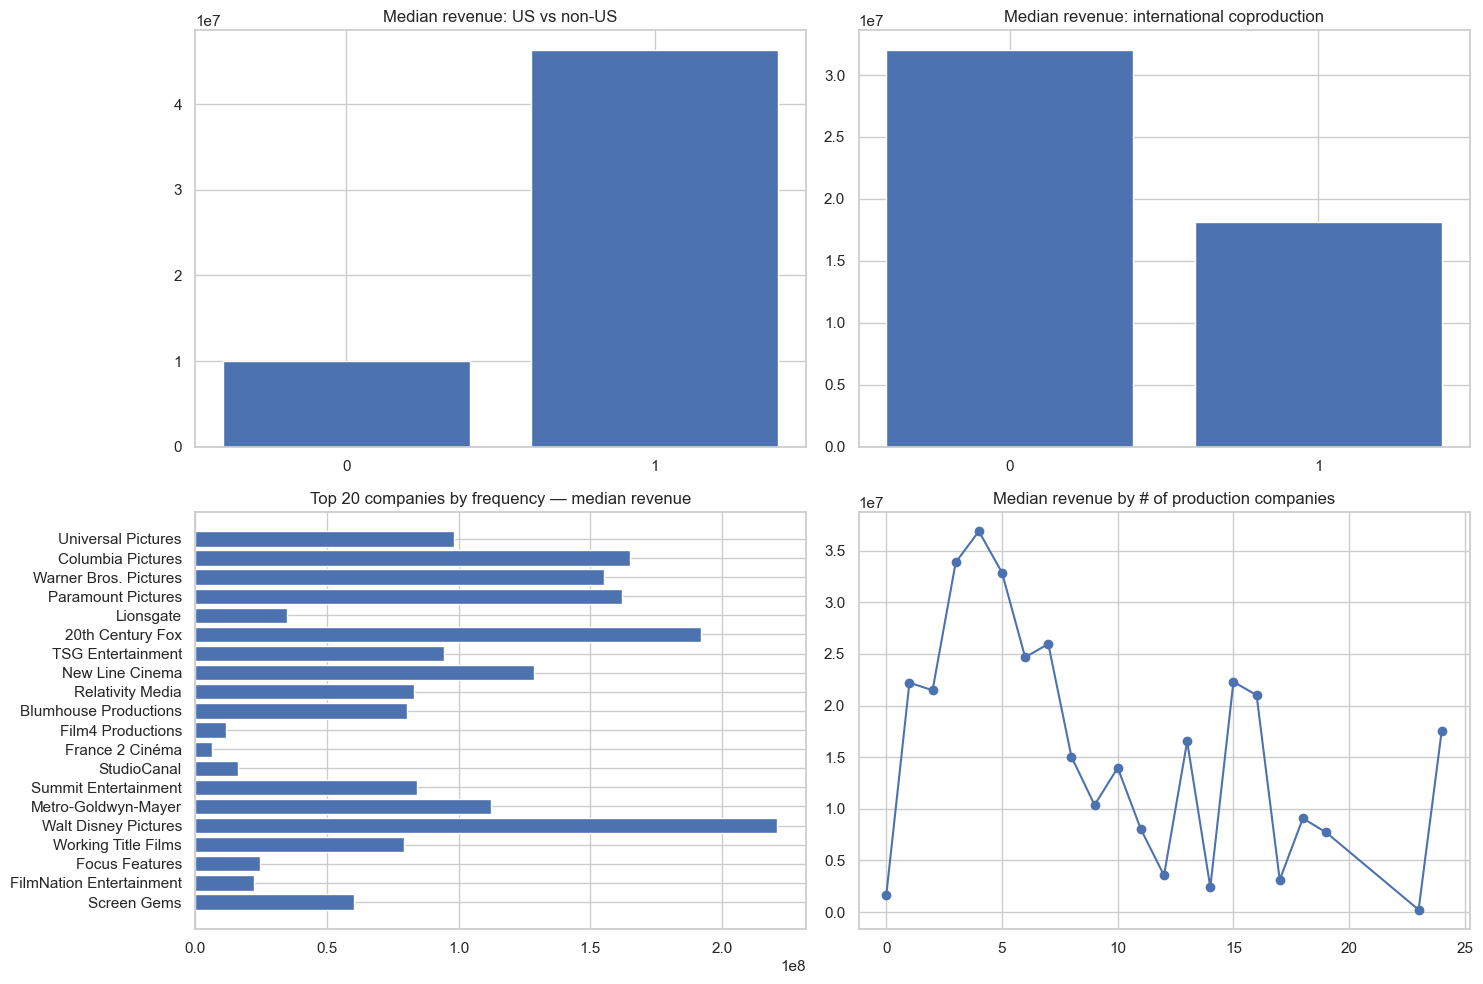

In [ ]:
#Country / company / coproduction analysis
prod_us = df_clean.groupby('is_us_production').agg(
    n_movies=('movie_id', 'count'),
    median_revenue=('revenue', 'median'),
    mean_log_revenue=('log_revenue', 'mean'),
    mean_budget=('budget', 'mean'),
    mean_tmdb_rating=('tmdb_vote_average', 'mean'),
).reset_index()

prod_intl = df_clean.groupby('is_international_coproduction').agg(
    n_movies=('movie_id', 'count'),
    median_revenue=('revenue', 'median'),
    mean_log_revenue=('log_revenue', 'mean'),
).reset_index()

ncomp_stats = df_clean.groupby('num_production_companies').agg(
    n_movies=('movie_id', 'count'),
    median_revenue=('revenue', 'median'),
    mean_log_revenue=('log_revenue', 'mean'),
).reset_index()

comp_rows = []
for _, r in df_clean.iterrows():
    for c in r['production_companies'][:5]:
        comp_rows.append({'company': c, 'revenue': r['revenue'], 'log_revenue': r['log_revenue']})
top_companies = (pd.DataFrame(comp_rows).groupby('company').agg(
    n_movies=('revenue', 'count'),
    median_revenue=('revenue', 'median'),
    mean_log_revenue=('log_revenue', 'mean'),
).reset_index().sort_values('n_movies', ascending=False).head(20))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0, 0].bar(prod_us['is_us_production'].astype(str), prod_us['median_revenue'])
axes[0, 0].set_title('Median revenue: US vs non-US')
axes[0, 1].bar(prod_intl['is_international_coproduction'].astype(str), prod_intl['median_revenue'])
axes[0, 1].set_title('Median revenue: international coproduction')
axes[1, 0].barh(top_companies['company'], top_companies['median_revenue']); axes[1, 0].invert_yaxis()
axes[1, 0].set_title('Top 20 companies by frequency — median revenue')
axes[1, 1].plot(ncomp_stats['num_production_companies'], ncomp_stats['median_revenue'], marker='o')
axes[1, 1].set_title('Median revenue by # of production companies')
plt.tight_layout()
plt.show()

## Part 6: Ratings Analysis

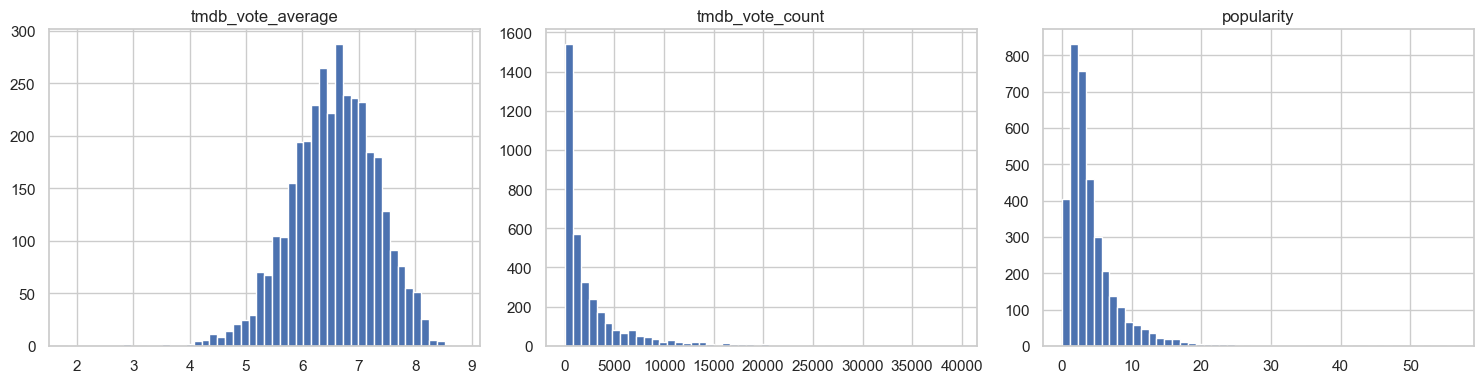

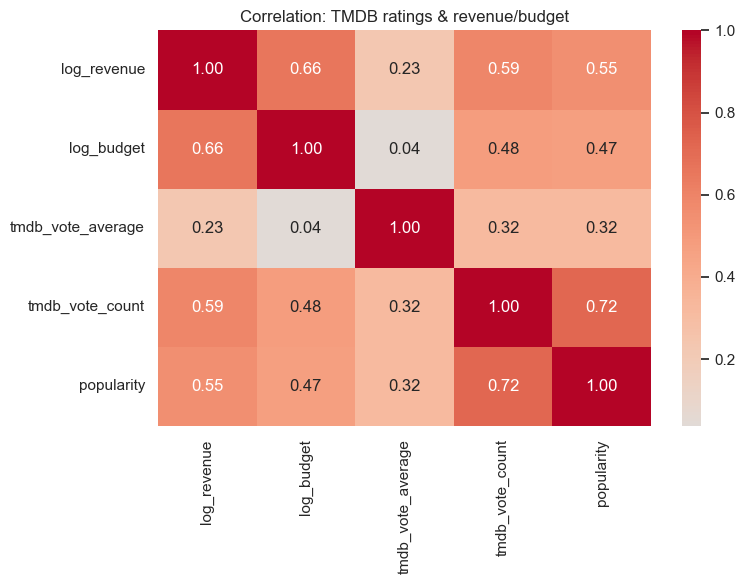

In [ ]:
#TMDB rating distributions & correlations
rating_cols = ['tmdb_vote_average', 'tmdb_vote_count', 'popularity']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, rating_cols):
    df_clean[col].dropna().hist(bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

corr_cols = ['log_revenue', 'log_budget'] + rating_cols
rating_corr = df_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(rating_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation: TMDB ratings & revenue/budget')
plt.tight_layout()
plt.show()

## Part 7: Cast & Director

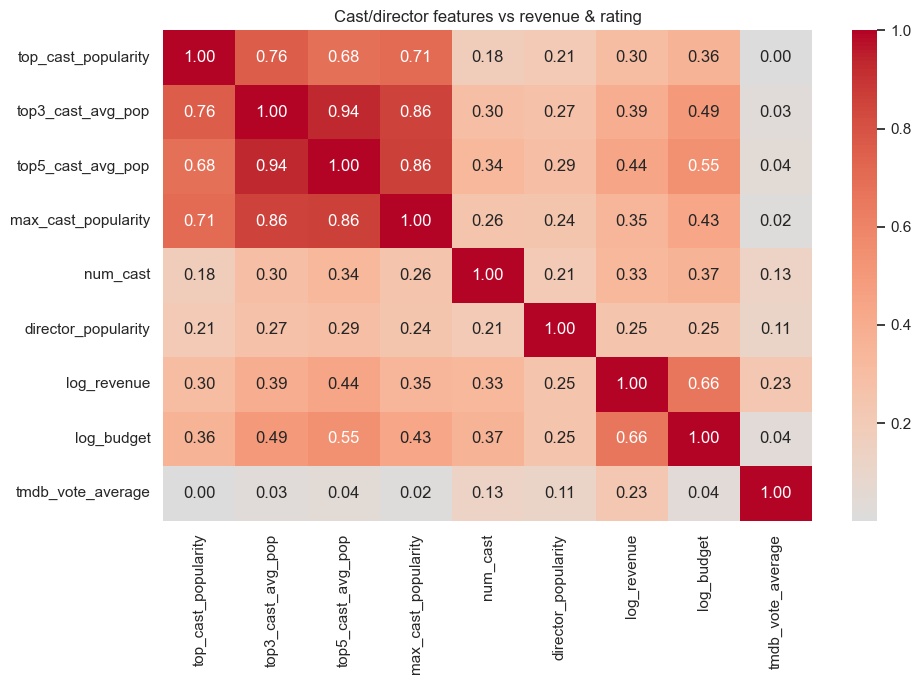

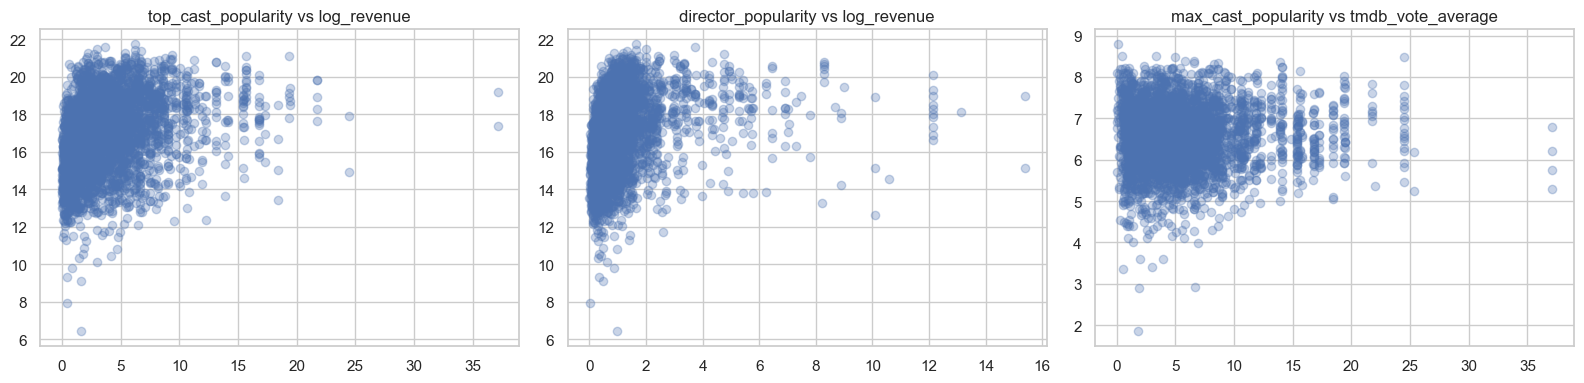

In [ ]:
#Cast/director popularity vs outcomes
cast_cols = ['top_cast_popularity', 'top3_cast_avg_pop', 'top5_cast_avg_pop',
             'max_cast_popularity', 'num_cast', 'director_popularity']

cast_corr = df_clean[cast_cols + ['log_revenue', 'log_budget', 'tmdb_vote_average']].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(cast_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Cast/director features vs revenue & rating')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(df_clean['top_cast_popularity'], df_clean['log_revenue'], alpha=0.3)
axes[0].set_title('top_cast_popularity vs log_revenue')
axes[1].scatter(df_clean['director_popularity'], df_clean['log_revenue'], alpha=0.3)
axes[1].set_title('director_popularity vs log_revenue')
axes[2].scatter(df_clean['max_cast_popularity'], df_clean['tmdb_vote_average'], alpha=0.3)
axes[2].set_title('max_cast_popularity vs tmdb_vote_average')
plt.tight_layout()
plt.show()

## Part 8: Text & Keywords

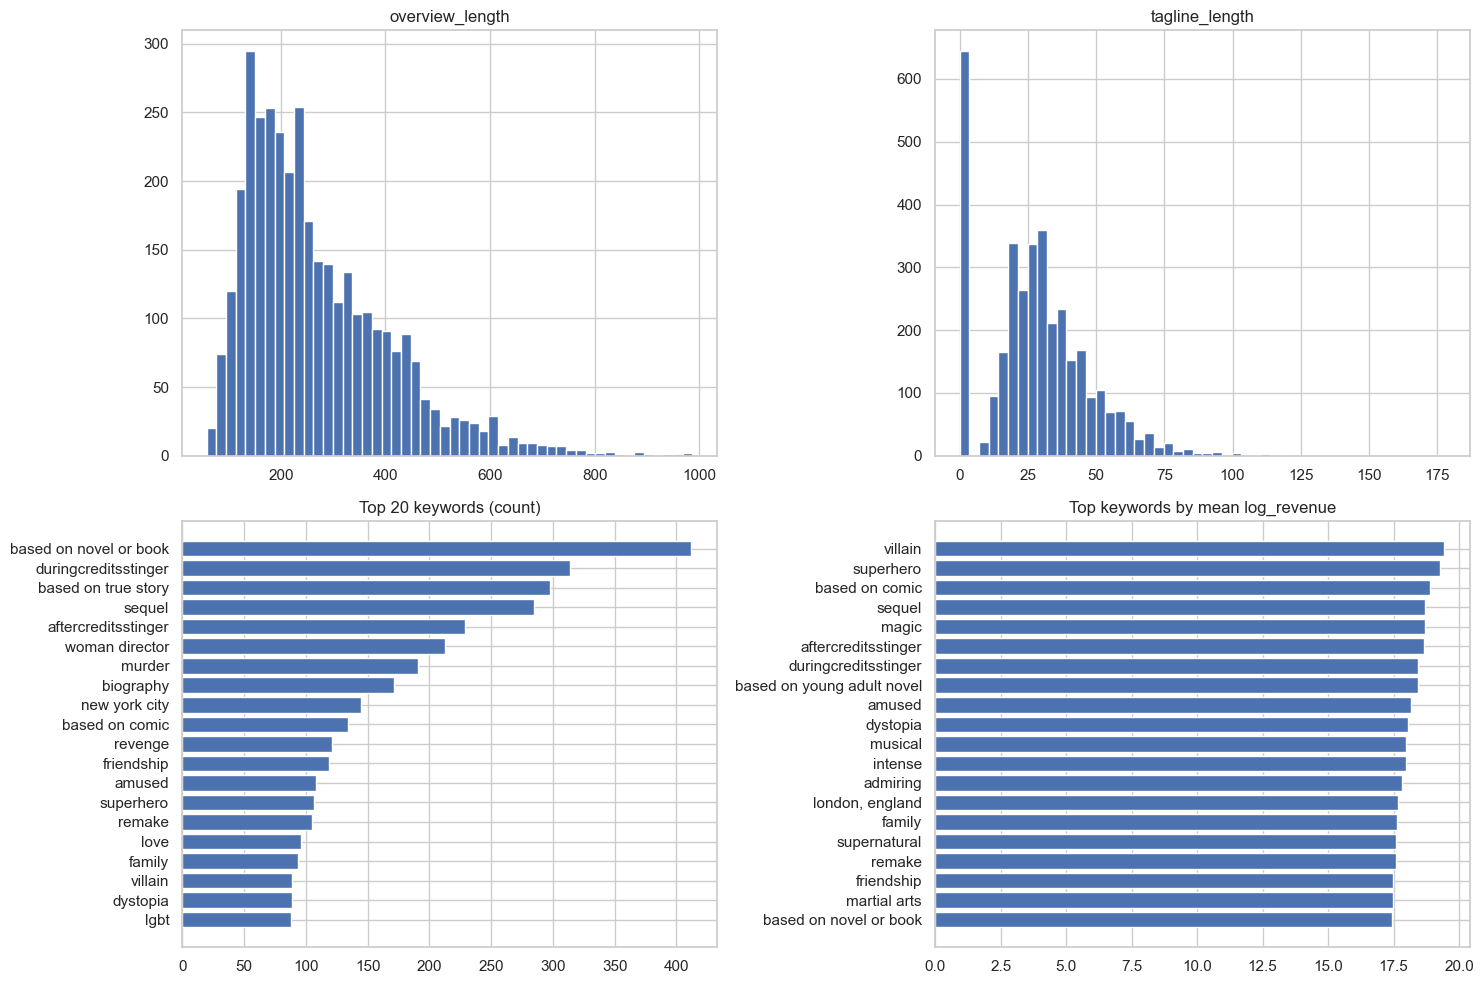

Has tagline ratio: 0.8173839184597962


In [ ]:
#Text length & keyword frequency
kw_counter = Counter()
for kws in df_clean['keywords']:
    kw_counter.update(kws)
top_kw = pd.DataFrame(kw_counter.most_common(40), columns=['keyword', 'count'])

top_kw_set = set(top_kw['keyword'])
kw_rows = []
for _, r in df_clean.iterrows():
    for k in r['keywords']:
        if k in top_kw_set:
            kw_rows.append({'keyword': k, 'log_revenue': r['log_revenue'],
                            'tmdb_vote_average': r['tmdb_vote_average']})
kw_stats = (pd.DataFrame(kw_rows).groupby('keyword').agg(
    n_movies=('log_revenue', 'count'),
    mean_log_revenue=('log_revenue', 'mean'),
    mean_rating=('tmdb_vote_average', 'mean'),
).reset_index().sort_values('mean_log_revenue', ascending=False))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
df_clean['overview_length'].hist(bins=50, ax=axes[0, 0]); axes[0, 0].set_title('overview_length')
df_clean['tagline_length'].hist(bins=50, ax=axes[0, 1]); axes[0, 1].set_title('tagline_length')
top20 = top_kw.head(20)
axes[1, 0].barh(top20['keyword'], top20['count']); axes[1, 0].invert_yaxis()
axes[1, 0].set_title('Top 20 keywords (count)')
top20r = kw_stats.head(20)
axes[1, 1].barh(top20r['keyword'], top20r['mean_log_revenue']); axes[1, 1].invert_yaxis()
axes[1, 1].set_title('Top keywords by mean log_revenue')
plt.tight_layout()
plt.show()

print('Has tagline ratio:', df_clean['has_tagline'].mean())